In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt


PROJECT = Path(r"Z:\Projects\monsoon-postprocessing")

GEFS_FOLDER = PROJECT / "data" / "raw" / "gefs_pilot"
IMERG_FOLDER = PROJECT / "data" / "raw" / "imerg_pilot"

OUTPUT_FILE = (
    PROJECT
    / "data"
    / "processed"
    / "pilot_gefs_imerg_20180701_20180707.nc"
)

In [2]:
gefs_files = sorted(GEFS_FOLDER.glob("*.grib2"))
imerg_files = sorted(IMERG_FOLDER.glob("*.nc4"))


# Map GEFS initialization dates to files.
gefs_by_initialization = {}

for file in gefs_files:
    match = re.search(
        r"apcp_sfc_(\d{10})_c00",
        file.name
    )

    if match:
        initialization = pd.to_datetime(
            match.group(1),
            format="%Y%m%d%H"
        )

        gefs_by_initialization[initialization] = file


# Map IMERG observation dates to files.
imerg_by_date = {}

for file in imerg_files:
    match = re.search(
        r"3IMERG\.(\d{8})-",
        file.name
    )

    if match:
        observation_date = pd.to_datetime(
            match.group(1),
            format="%Y%m%d"
        )

        imerg_by_date[observation_date] = file


print("GEFS files mapped:", len(gefs_by_initialization))
print("IMERG files mapped:", len(imerg_by_date))

GEFS files mapped: 7
IMERG files mapped: 7


In [4]:
def process_gefs_file(file):
    """Create +24 to +48-hour rainfall over India."""

    ds = xr.open_dataset(
        file,
        engine="cfgrib",
        backend_kwargs={
            "filter_by_keys": {
                "typeOfLevel": "surface"
            },
            "indexpath": ""
        }
    )

    variable_name = (
        "tp"
        if "tp" in ds.data_vars
        else list(ds.data_vars)[0]
    )

    rain = ds[variable_name]

    step_hours = (
        rain.step / np.timedelta64(1, "h")
    ).astype(int)

    selected = rain.where(
        (step_hours > 24)
        & (step_hours <= 48),
        drop=True
    )

    selected_hours = (
        selected.step / np.timedelta64(1, "h")
    ).astype(int).values.tolist()

    expected_hours = [
        27, 30, 33, 36,
        39, 42, 45, 48
    ]

    if selected_hours != expected_hours:
        ds.close()

        raise ValueError(
            f"Unexpected steps in {file.name}: "
            f"{selected_hours}"
        )

    rain_24h = selected.sum(
        dim="step",
        skipna=True
    )

    rain_24h = rain_24h.where(
        (rain_24h.latitude >= 6)
        & (rain_24h.latitude <= 38)
        & (rain_24h.longitude >= 68)
        & (rain_24h.longitude <= 98),
        drop=True
    )

    rain_24h = rain_24h.sortby("latitude")
    rain_24h = rain_24h.sortby("longitude")
    rain_24h = rain_24h.load()

    ds.close()

    # Remove unnecessary scalar GRIB coordinates.
    cleaned = xr.DataArray(
        rain_24h.values,
        coords={
            "latitude": rain_24h.latitude.values,
            "longitude": rain_24h.longitude.values
        },
        dims=("latitude", "longitude"),
        name="gefs_rainfall"
    )

    cleaned.attrs = {
        "long_name": "GEFS 24-hour forecast rainfall",
        "units": "mm",
        "lead_period": "24-48 hours"
    }

    return cleaned

In [9]:
from netCDF4 import Dataset


def process_imerg_file(file, target_grid):
    """Prepare IMERG and interpolate it to the GEFS grid."""

    # Check whether this file contains a Grid group.
    with Dataset(file, mode="r") as root:
        groups = list(root.groups.keys())

    open_options = {
        "engine": "netcdf4"
    }

    if "Grid" in groups:
        open_options["group"] = "Grid"

    with xr.open_dataset(
        file,
        **open_options
    ) as ds:
        if "precipitation" not in ds.data_vars:
            raise KeyError(
                f"precipitation not found in {file.name}. "
                f"Available variables: {list(ds.data_vars)}"
            )

        rain = ds["precipitation"].load()

    # Remove the single daily time dimension.
    if "time" in rain.dims and rain.sizes["time"] == 1:
        rain = rain.squeeze(
            dim="time",
            drop=True
        )

    rename_map = {}

    if "lat" in rain.dims or "lat" in rain.coords:
        rename_map["lat"] = "latitude"

    if "lon" in rain.dims or "lon" in rain.coords:
        rename_map["lon"] = "longitude"

    rain = rain.rename(rename_map)

    rain = rain.transpose(
        "latitude",
        "longitude"
    )

    rain = rain.sortby("latitude")
    rain = rain.sortby("longitude")

    # Crop the India-region bounding box.
    rain = rain.where(
        (rain.latitude >= 6)
        & (rain.latitude <= 38)
        & (rain.longitude >= 68)
        & (rain.longitude <= 98),
        drop=True
    )

    # Match IMERG to the GEFS grid.
    matched = rain.interp(
        latitude=target_grid.latitude,
        longitude=target_grid.longitude,
        method="linear"
    )

    matched.name = "imerg_rainfall"

    matched.attrs = {
        "long_name": "IMERG rainfall on GEFS grid",
        "units": "mm",
        "original_units": "mm/day",
        "interpolation": "linear"
    }

    return matched

In [10]:
observation_dates = pd.date_range(
    start="2018-07-01",
    end="2018-07-07",
    freq="D"
)

daily_datasets = []


for observation_date in observation_dates:
    initialization_date = (
        observation_date
        - pd.Timedelta(days=1)
    )

    if initialization_date not in gefs_by_initialization:
        raise FileNotFoundError(
            f"Missing GEFS file for "
            f"{initialization_date.date()}"
        )

    if observation_date not in imerg_by_date:
        raise FileNotFoundError(
            f"Missing IMERG file for "
            f"{observation_date.date()}"
        )

    gefs_rain = process_gefs_file(
        gefs_by_initialization[
            initialization_date
        ]
    )

    imerg_rain = process_imerg_file(
        imerg_by_date[observation_date],
        gefs_rain
    )

    error = gefs_rain - imerg_rain
    error.name = "forecast_error"
    error.attrs["units"] = "mm"

    daily_ds = xr.Dataset({
        "gefs_rainfall": gefs_rain,
        "imerg_rainfall": imerg_rain,
        "forecast_error": error
    })

    daily_ds = daily_ds.expand_dims(
        date=[observation_date.to_datetime64()]
    )

    daily_datasets.append(daily_ds)

    print(
        "Processed:",
        observation_date.date(),
        "| GEFS initialization:",
        initialization_date.date()
    )

Processed: 2018-07-01 | GEFS initialization: 2018-06-30
Processed: 2018-07-02 | GEFS initialization: 2018-07-01
Processed: 2018-07-03 | GEFS initialization: 2018-07-02
Processed: 2018-07-04 | GEFS initialization: 2018-07-03
Processed: 2018-07-05 | GEFS initialization: 2018-07-04
Processed: 2018-07-06 | GEFS initialization: 2018-07-05
Processed: 2018-07-07 | GEFS initialization: 2018-07-06


In [11]:
pilot_ds = xr.concat(
    daily_datasets,
    dim="date"
)

pilot_ds.attrs = {
    "title": "Seven-day GEFS and IMERG pilot dataset",
    "period": "2018-07-01 to 2018-07-07",
    "forecast_source": "NOAA GEFSv12 reforecast c00",
    "observation_source": "NASA GPM IMERG Final V07",
    "forecast_lead": "24-48 hours",
    "error_definition": "GEFS minus IMERG"
}

print(pilot_ds)
print("Dates:", pilot_ds.date.values)

<xarray.Dataset> Size: 2MB
Dimensions:         (date: 7, latitude: 129, longitude: 121)
Coordinates:
  * date            (date) datetime64[us] 56B 2018-07-01 ... 2018-07-07
  * latitude        (latitude) float64 1kB 6.0 6.25 6.5 6.75 ... 37.5 37.75 38.0
  * longitude       (longitude) float64 968B 68.0 68.25 68.5 ... 97.5 97.75 98.0
Data variables:
    gefs_rainfall   (date, latitude, longitude) float32 437kB 1.91 1.21 ... 13.7
    imerg_rainfall  (date, latitude, longitude) float64 874kB nan nan ... nan
    forecast_error  (date, latitude, longitude) float64 874kB nan nan ... nan
Attributes:
    title:               Seven-day GEFS and IMERG pilot dataset
    period:              2018-07-01 to 2018-07-07
    forecast_source:     NOAA GEFSv12 reforecast c00
    observation_source:  NASA GPM IMERG Final V07
    forecast_lead:       24-48 hours
    error_definition:    GEFS minus IMERG
Dates: ['2018-07-01T00:00:00.000000' '2018-07-02T00:00:00.000000'
 '2018-07-03T00:00:00.000000' '2018-07

In [14]:
summary_rows = []

for date in pilot_ds.date.values:
    daily = pilot_ds.sel(date=date)

    summary_rows.append({
        "date": pd.Timestamp(date).date(),
        "gefs_mean": float(
            daily["gefs_rainfall"].mean(
                skipna=True
            )
        ),
        "imerg_mean": float(
            daily["imerg_rainfall"].mean(
                skipna=True
            )
        ),
        "mean_error": float(
            daily["forecast_error"].mean(
                skipna=True
            )
        ),
        "gefs_max": float(
            daily["gefs_rainfall"].max(
                skipna=True
            )
        ),
        "imerg_max": float(
            daily["imerg_rainfall"].max(
                skipna=True
            )
        )
    })


summary_df = pd.DataFrame(summary_rows)
summary_df


,date,gefs_mean,imerg_mean,mean_error,gefs_max,imerg_max
0,2018-07-01,11.300482,6.585499,4.841639,335.600006,151.800003
1,2018-07-02,13.650534,7.904381,5.954987,401.179993,156.095001
2,2018-07-03,13.486231,7.606247,6.050426,188.250000,273.917496
3,2018-07-04,13.330415,8.198208,5.258902,265.780029,254.345001
4,2018-07-05,12.204253,7.915879,4.377851,167.809998,253.055023
5,2018-07-06,11.245246,7.546630,3.664125,143.199982,249.272507
6,2018-07-07,11.687757,6.580757,5.269948,130.100006,168.705009


In [15]:
OUTPUT_FILE.parent.mkdir(
    parents=True,
    exist_ok=True
)

encoding = {
    variable: {
        "zlib": True,
        "complevel": 4
    }
    for variable in pilot_ds.data_vars
}

pilot_ds.to_netcdf(
    OUTPUT_FILE,
    mode="w",
    engine="netcdf4",
    encoding=encoding
)

print("Saved:", OUTPUT_FILE.exists())
print("Location:", OUTPUT_FILE)
print(
    "Size:",
    OUTPUT_FILE.stat().st_size / 1_000_000,
    "MB"
)

Saved: True
Location: Z:\Projects\monsoon-postprocessing\data\processed\pilot_gefs_imerg_20180701_20180707.nc
Size: 1.235752 MB


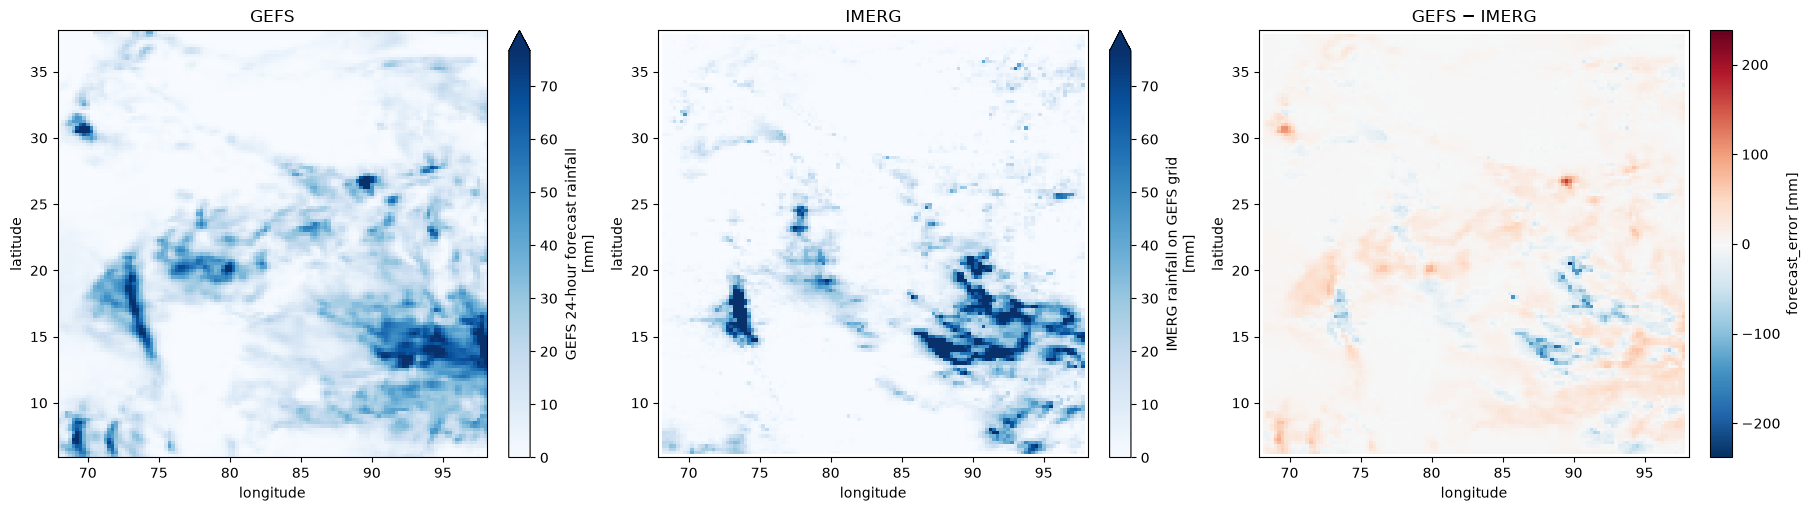

In [16]:
sample_date = "2018-07-05"

sample = pilot_ds.sel(date=sample_date)

comparison_max = float(
    np.nanpercentile(
        np.concatenate([
            sample["gefs_rainfall"].values.ravel(),
            sample["imerg_rainfall"].values.ravel()
        ]),
        99
    )
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    constrained_layout=True
)

sample["gefs_rainfall"].plot(
    ax=axes[0],
    cmap="Blues",
    vmin=0,
    vmax=comparison_max
)
axes[0].set_title("GEFS")

sample["imerg_rainfall"].plot(
    ax=axes[1],
    cmap="Blues",
    vmin=0,
    vmax=comparison_max
)
axes[1].set_title("IMERG")

sample["forecast_error"].plot(
    ax=axes[2],
    cmap="RdBu_r",
    center=0
)
axes[2].set_title("GEFS − IMERG")

plt.show()